# Assignment: Exploratory Data Analysis

**Q1.** In class, we talked about how to compute the sample mean of a variable $X$,
$$
m(X) = \dfrac{1}{N} \sum_{i=1}^N x_i
$$
and sample covariance of two variables $X$ and $Y$,
$$
\text{cov}(X,Y) = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))(y_i - m(Y))).
$$
Recall, the sample variance of $X$ is
$$
s^2 = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))^2.
$$
It can be very helpful to understand some basic properties of these statistics. If you want to write your calculations on a piece of paper, take a photo, and upload that to your GitHub repo, that's probably easiest.

1. Show that $m(a + bX) = a+b \times m(X)$.
2. Show that $\text{cov}(X,a+bY) = b \times \text{cov}(X,Y)$
3. Show that $\text{cov}(a+bX,a+bX) = b^2 \text{cov}(X,X) $, and in particular that $\text{cov}(X,X) = s^2 $.
4. Consider a non-decreasing transformation $g()$. Is is always true that $m(g(X))= g(m(X))$?

**Q2.** This question looks at financial transfers from foreign entities to American universities. In particular, from which countries and giftors are the gifts coming from, and to which institutions are they going? For this question, `.groupby([vars]).count()` and `.groupby([vars]).sum()` will be especially useful to tally the number of occurrences and sum the values of those occurrences.

1. Load the `./data/ForeignGifts_edu.csv` dataset.
2. For `Foreign Gift Amount`, create a histogram and describe the variable. Describe your findings.
3. For `Gift Type`, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?
4. Create a kernel density plot of the log of `Foreign Gift Amount`, and then a kernel density plot of the log of `Foreign Gift Amount` conditional on gift type. Do you notice any patterns?
5. What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?
6. Which giftors provide the most money, in total?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Angel Pavu

**Date:** 09/09/2026

# Part 1 Solution from my paper
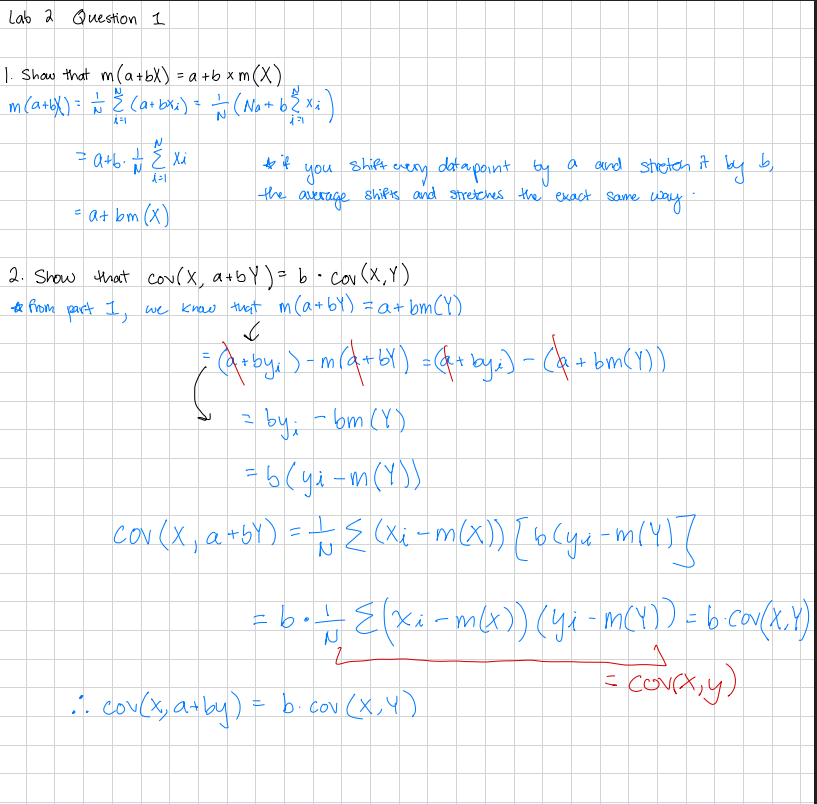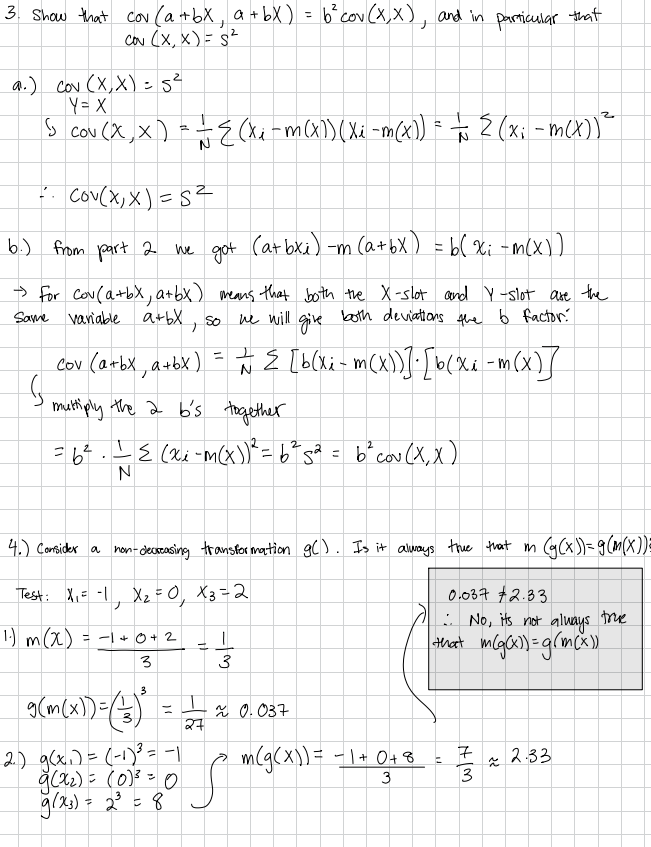

In [ ]:
# Your Phase 1 solution to the problem goes here.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/ForeignGifts_edu.csv')

In [ ]:
# Look at the rows
df.head(5)

,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
0,1,102000,Jacksonville State University,Jacksonville,AL,43738,250000,Monetary Gift,CHINA,NaN
1,2,104700,Troy University,Troy,AL,43592,463657,Contract,CHINA,Confucius Institute Headquarters
2,3,105100,University of Alabama,Tuscaloosa,AL,43466,3649107,Contract,ENGLAND,Springer Nature Customer Service Ce
3,4,105100,University of Alabama,Tuscaloosa,AL,43472,1000,Contract,SAUDI ARABIA,Saudi Arabia Education Mission
4,5,105100,University of Alabama,Tuscaloosa,AL,43479,49476,Contract,SAUDI ARABIA,Saudi Arabia Education Mission


(array([2.602e+04, 1.292e+03, 3.690e+02, 1.950e+02, 7.000e+01, 5.000e+01,
        4.600e+01, 1.800e+01, 1.300e+01, 1.500e+01, 1.100e+01, 1.000e+01,
        5.000e+00, 5.000e+00, 1.000e+01, 1.400e+01, 8.000e+00, 7.000e+00,
        6.000e+00, 5.000e+00, 3.000e+00, 2.000e+00, 5.000e+00, 2.000e+00,
        3.000e+00, 2.000e+00, 0.000e+00, 1.000e+00, 3.000e+00, 2.000e+00,
        2.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        1.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 1.000e+00, 1.000e+00,
        0.000e+00, 0.000e+00, 4.000e+00, 1.000e+01, 1.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 7.000e+00]),
 array([ -537770.        ,  1137859.48333333,  2813488.96666667,
         4489118.45      ,  6164747.93333333,  7840377.41666667,
         9516006.9       , 11191636.38333333, 12867265.86666667,
        14542895.35      , 16218524.83333333, 17894154.31666667

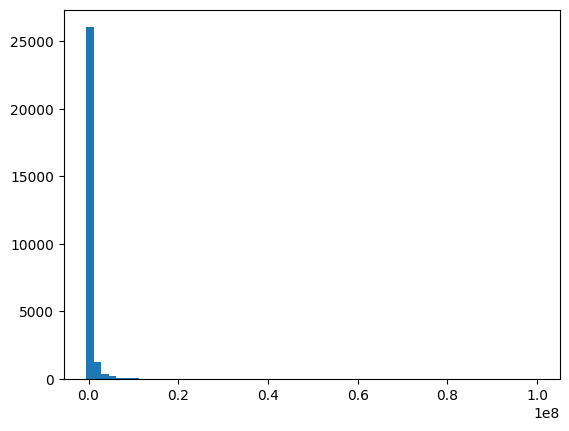

In [ ]:
# Histogram and Variable Description
plt.hist(df['Foreign Gift Amount'], bins=60)
print(df['Foreign Gift Amount'].describe())

Describing Findings: The current histogram is really hard to make meaning out of since it is mostly concentrated at 0 and everything else invisible, because a handful of gifts are huge dollar amounts (10M-100M) compared to the majority of gifts which are a few thousand to a few hundred thousand dollars. The variable seems to be closer to log-normally distributed than normally distributed.

In [ ]:
# Value Counts Table
df['Gift Type'].value_counts()

,count
Gift Type,
Contract,17274
Monetary Gift,10936
Real Estate,11


In [ ]:
# Proportion of each gift type
df['Gift Type'].value_counts(normalize=True)

,proportion
Gift Type,
Contract,0.612097
Monetary Gift,0.387513
Real Estate,0.000390


<Axes: xlabel='log_scale', ylabel='Density'>

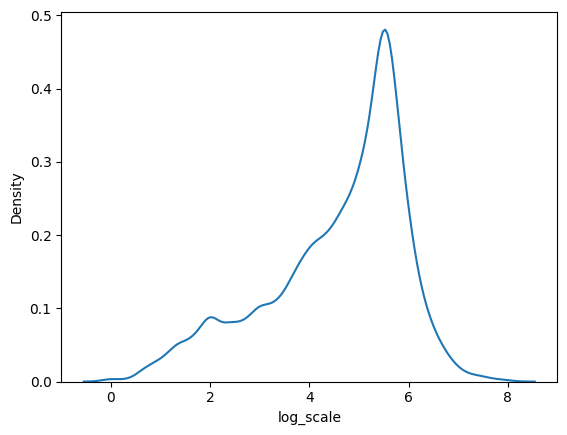

In [ ]:
# Overall kernel density plot of the log of Foreign Gift Amount
# drop negatives values before taking the log
df_pos = df[df['Foreign Gift Amount'] > 0].copy()
df_pos['log_scale'] = np.log10(df_pos['Foreign Gift Amount'])

sns.kdeplot(df_pos['log_scale'])

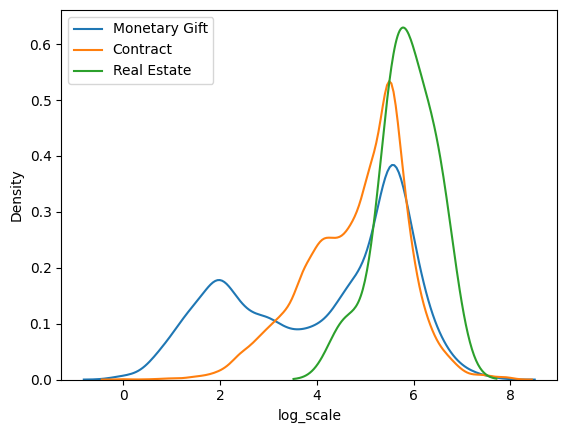

In [ ]:
# Kernel density plot of the log of Foreign Gift Amount by gift type
for gt in df_pos['Gift Type'].unique():
    sns.kdeplot(df_pos.loc[df_pos['Gift Type']==gt, 'log_scale'], label=gt)
plt.legend()

I notice a pattern between the overall kernel density plot of the log of Foreign Gift Amount and the kernal density plot broken up by type. Both plots follow the same general shape, as there are peaks of the density at the higher log amounts, and this stays consistent with each of the 3 gift types.

In [ ]:
# Top 15 countries by number of gifts


,0
Country of Giftor,
ENGLAND,3655
CHINA,2461
CANADA,2344
JAPAN,1896
SWITZERLAND,1676
SAUDI ARABIA,1610
FRANCE,1437
GERMANY,1394
HONG KONG,1080


In [ ]:
# Top 15 countries by amount given
df.groupby('Country of Giftor').sum(numeric_only=True)['Foreign Gift Amount'].sort_values(ascending=False).head(15)

,Foreign Gift Amount
Country of Giftor,
QATAR,2706240869
ENGLAND,1464906771
CHINA,1237952112
SAUDI ARABIA,1065205930
BERMUDA,899593972
CANADA,898160656
HONG KONG,887402529
JAPAN,655954776
SWITZERLAND,619899445


I would say there is some correlation here, as England and China are in the top 3 of countries by number of gifts and by amount given. However, Qatar has the most in total dollars despite ranking 11th in count. This means that Qatar might have a small number of very large gifts.

In [ ]:
# Giftors that provide the most money total
df.groupby('Giftor Name').sum(numeric_only=True)['Foreign Gift Amount'].sort_values(ascending=False).head(15)

,Foreign Gift Amount
Giftor Name,
Qatar Foundation,1166503744
Qatar Foundation/Qatar National Res,796197000
Qatar Foundation for Education,373945215
Anonymous,338793629
Saudi Arabian Cultural Mission,275221475
HCL,190000000
Church of Jesus Christ of LDS,185203715
Emirates Institute for Advanced Sc,170641244
QIC,148355497


It appears that giftors from Qatar have given the most money total, as they occupy the top 3 positions in the total overall foreign gift amount.

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** d132bab10220c467515ad024c904a4f32387772f
- **AI tool and model used:** Claude Sonnet 5

### *Prompts used

1. I have attatched an ipynb notebook for my lab 2. Please go through it and let me know of any changes/revisions that need to be made that would be more optimal/thorough than I currently have down. Do not immediately change anything, just give me a few numbered suggestions on improvements to make.
2. How would you implement changing the x axis from log scale to actual numeric values?

[Paste the AI's concise numbered list verbatim.]

1. Cell 16 (Top 15 countries by number of gifts) is empty. This is part of Q2.5 and needs to be filled in — something like df.groupby('Country of Giftor').size().sort_values(ascending=False).head(15) (or .count() on a non-null column).

2. Label the KDE x-axis in actual dollar amounts, not raw log values. Right now the x-axis of your KDE plots just shows the log10-transformed numbers, which forces the reader to do mental math to know what they mean. Since the log transform is only there to handle the skew, keep the underlying data log-scaled but relabel the tick marks with the actual dollar amounts they correspond to (e.g., $1K, $10K, $100K, $1M, $10M) rather than showing 3, 4, 5, 6, 7. That way the plot keeps the statistical benefit of the log transform while staying readable in the dollar terms the assignment is actually about. This can be done with plt.xticks()/custom tick formatting (e.g., matplotlib.ticker.FuncFormatter), or alternatively by using a log-scaled x-axis (plt.xscale('log')) on the raw (untransformed) Foreign Gift Amount values instead of manually log-transforming the column — that approach lets matplotlib handle the dollar-labeled ticks automatically.

3. one small gap is in Part 4: you use g(x)=x3g(x)=x3
 as your counterexample but never explicitly justify why it qualifies as "non-decreasing" (the condition the question requires). Adding a one-line justification (e.g., via the derivative) closes that gap and makes the proof fully rigorous.

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept| I believe I accidently deleted the code piece for that block while I was moving things around, because the actual image of my result shows up but not the code, so I probably accidently deleted before committing my code. It is important I add that part of the solution as it is important to the assignment to see how I got those numbers.|
| 2 | Accept | It will be confusing to someone who is not familary with logarithmic properties to understand the current KDE plots as is, so converting it into a numeric dollar value is more easily interpretable for a wider audience. I believe this was the best suggestion given, as I too was thinking of this while doing the assignment, but I just did not know how to implement it.  |
| 3 | Accept | This is more so a suggestion regarding my explanation rather than errors found in the work, but I agree with the AI's suggestion of adding an extra sentence as an explanation as to why it qualifies as non-decreasing.  |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

# Question 1 AI Suggestion Solution
**4. Non-decreasing transformation g()**

It is not always true that the mean of the transformed variable equals the transform of the mean.

Counterexample: Let g be the cubing function, meaning it raises a number to the third power.
The rate of change of this function is always zero or positive (it never decreases), so cubing
qualifies as a non-decreasing function, which satisfies the condition in the problem.

Take a variable X with three values: negative one, zero, and two.

First, find the mean of X: add the three values together and divide by three, which gives
one third. Now cube that mean: one third cubed is one over twenty-seven, which is
approximately 0.037.

Next, do it the other way around: cube each value of X first. Negative one cubed is negative
one, zero cubed is zero, and two cubed is eight. Now take the mean of these cubed values:
add negative one, zero, and eight together and divide by three, which gives seven thirds,
approximately 2.33.

Since 0.037 does not equal 2.33, this shows that the mean of the transformed variable is not
equal to the transform of the mean, even for a non-decreasing function like cubing.

# Question 2 AI Suggestion Solution

In [1]:
# Your Phase 2 solution to the problem goes here.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

df = pd.read_csv('/content/ForeignGifts_edu.csv')

# Look at the rows
df.head(5)


,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
0,1,102000,Jacksonville State University,Jacksonville,AL,43738,250000,Monetary Gift,CHINA,NaN
1,2,104700,Troy University,Troy,AL,43592,463657,Contract,CHINA,Confucius Institute Headquarters
2,3,105100,University of Alabama,Tuscaloosa,AL,43466,3649107,Contract,ENGLAND,Springer Nature Customer Service Ce
3,4,105100,University of Alabama,Tuscaloosa,AL,43472,1000,Contract,SAUDI ARABIA,Saudi Arabia Education Mission
4,5,105100,University of Alabama,Tuscaloosa,AL,43479,49476,Contract,SAUDI ARABIA,Saudi Arabia Education Mission


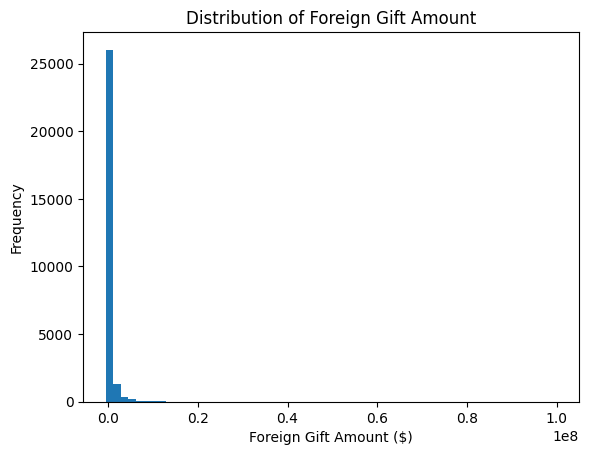

count    2.822100e+04
mean     5.882327e+05
std      3.222011e+06
min     -5.377700e+05
25%      5.700000e+03
50%      9.461500e+04
75%      3.761420e+05
max      1.000000e+08
Name: Foreign Gift Amount, dtype: float64


In [2]:
# Histogram and Variable Description
plt.hist(df['Foreign Gift Amount'], bins=60)
plt.title('Distribution of Foreign Gift Amount')
plt.xlabel('Foreign Gift Amount ($)')
plt.ylabel('Frequency')
plt.show()
print(df['Foreign Gift Amount'].describe())

Describing Findings: The current histogram is really hard to make meaning out of since it is mostly concentrated at 0 and everything else invisible, because a handful of gifts are huge
dollar amounts (10M-100M) compared to the majority of gifts which are a few thousand to a few
hundred thousand dollars. The variable seems to be closer to log-normally distributed than normally distributed.

In [7]:
# Value Counts Table
df['Gift Type'].value_counts()

,count
Gift Type,
Contract,17274
Monetary Gift,10936
Real Estate,11


In [8]:
# Proportion of each gift type
df['Gift Type'].value_counts(normalize=True)

,proportion
Gift Type,
Contract,0.612097
Monetary Gift,0.387513
Real Estate,0.000390


In [9]:
# ----------------------------------------------------------------------------------
# AI-suggested change #2 implemented below: instead of leaving the KDE x-axis in raw
# log10 units (e.g. 3, 4, 5, 6), we relabel the ticks with the actual dollar amounts
# they correspond to (e.g. $1K, $10K, $100K, $1M), so the plot stays readable in the
# terms the assignment is actually about while keeping the benefit of the log transform.
# ----------------------------------------------------------------------------------

def dollar_formatter(log_val, pos):
    """Convert a log10-scaled tick value back into a readable dollar label."""
    val = 10 ** log_val
    if val >= 1_000_000:
        return f'${val/1_000_000:.0f}M'
    elif val >= 1_000:
        return f'${val/1_000:.0f}K'
    else:
        return f'${val:.0f}'


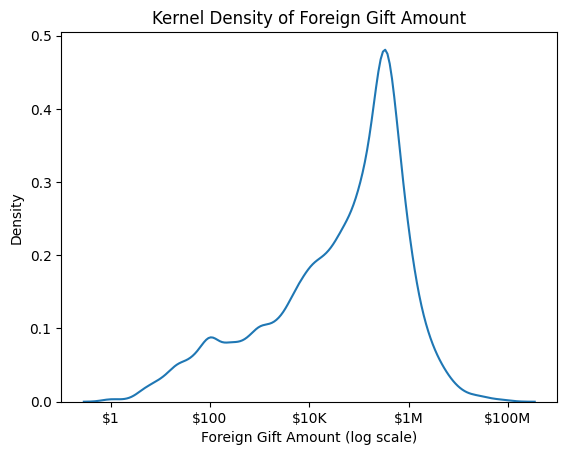

In [10]:
# Overall kernel density plot of the log of Foreign Gift Amount
# drop negative/zero values before taking the log
df_pos = df[df['Foreign Gift Amount'] > 0].copy()
df_pos['log_scale'] = np.log10(df_pos['Foreign Gift Amount'])

ax = sns.kdeplot(df_pos['log_scale'])
ax.xaxis.set_major_formatter(mticker.FuncFormatter(dollar_formatter))
plt.xlabel('Foreign Gift Amount (log scale)')
plt.title('Kernel Density of Foreign Gift Amount')
plt.show()


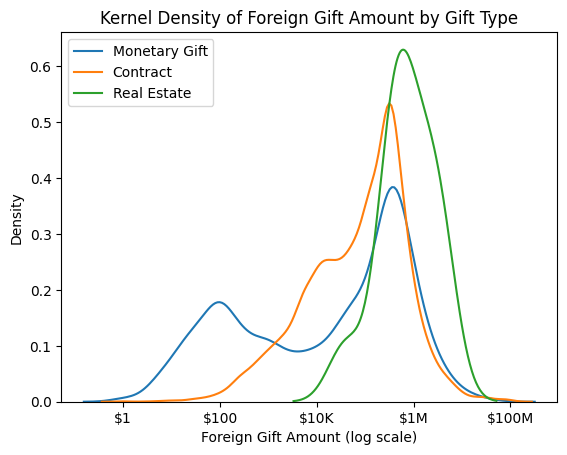

In [11]:
# Kernel density plot of the log of Foreign Gift Amount by gift type
ax = plt.gca()
for gt in df_pos['Gift Type'].unique():
    sns.kdeplot(df_pos.loc[df_pos['Gift Type'] == gt, 'log_scale'], label=gt, ax=ax)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(dollar_formatter))
plt.xlabel('Foreign Gift Amount (log scale)')
plt.title('Kernel Density of Foreign Gift Amount by Gift Type')
plt.legend()
plt.show()

 I notice a pattern between the overall kernel density plot of the log of Foreign Gift Amount and the kernel density plot broken up by type. Both plots follow the same general shape, as there are peaks of the density at the higher log amounts, and this stays consistent with each of the 3 gift types. After changing the x axis scale to monetary value, it is easier to see how much money each gift type has the most density at, rather than trying to decipher the numbers on the log_scale.

In [12]:
# ----------------------------------------------------------------------------------
# AI-suggested change #1 implemented below: this cell was previously empty. Filling in
# the top 15 countries by NUMBER of gifts (as opposed to by dollar amount, which is
# computed in the next cell) using groupby().size().
# ----------------------------------------------------------------------------------

# Top 15 countries by number of gifts
df.groupby('Country of Giftor').size().sort_values(ascending=False).head(15)

,0
Country of Giftor,
ENGLAND,3655
CHINA,2461
CANADA,2344
JAPAN,1896
SWITZERLAND,1676
SAUDI ARABIA,1610
FRANCE,1437
GERMANY,1394
HONG KONG,1080


In [13]:
# Top 15 countries by amount given
df.groupby('Country of Giftor').sum(numeric_only=True)['Foreign Gift Amount'].sort_values(ascending=False).head(15)

,Foreign Gift Amount
Country of Giftor,
QATAR,2706240869
ENGLAND,1464906771
CHINA,1237952112
SAUDI ARABIA,1065205930
BERMUDA,899593972
CANADA,898160656
HONG KONG,887402529
JAPAN,655954776
SWITZERLAND,619899445


I would say there is some correlation here, as England and China are in the top 3 of countries by number of gifts and by amount given. However, Qatar has the most in total dollars despite ranking 11th in count. This means that Qatar might have a small number of very large gifts.

In [14]:
# Giftors that provide the most money total
df.groupby('Giftor Name').sum(numeric_only=True)['Foreign Gift Amount'].sort_values(ascending=False).head(15)

# It appears that giftors from Qatar have given the most money total, as they occupy the top 3 positions in the total overall foreign gift amount.

,Foreign Gift Amount
Giftor Name,
Qatar Foundation,1166503744
Qatar Foundation/Qatar National Res,796197000
Qatar Foundation for Education,373945215
Anonymous,338793629
Saudi Arabian Cultural Mission,275221475
HCL,190000000
Church of Jesus Christ of LDS,185203715
Emirates Institute for Advanced Sc,170641244
QIC,148355497


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]

The AI-assisted revision gave me three main improvements in my Phase 1 solution. First, the empty cell for the top 15 countries by number of gifts was filled in using a groupby().size() operation, which was a straightforward but necessary fix since that part
of Q2.5 had been left incomplete.
Second, the AI suggested improving the KDE plots by
relabeling the x-axis in actual dollar amounts (e.g., $1K, $10K, $1M) instead of raw log10 values, which made the plots much more interpretable for a non technical audience without losing the benefit of the log transformation for handling the skewed data.

One limitation of the AI's suggestions was that they were general good practices (missing data checks, axis labeling, giftor/country name consistency) rather than issues specific to patterns in this dataset as the AI couldn't actually see the data itself, so some suggestions
required me to verify they applied before implementing them. For example I had to run the code myself to confirm the top 15 by count results were reasonable and consistent with the country-level conclusions I'd already drawn in Phase 1 (ex. about Qatar ranking high in
total dollars despite a lower gift count).

To verify the AI-assisted changes, I ran the updated code and checked that the dollar-labeled KDE plots rendered correctly and that the new top 15 by count table produced sensible country names and counts consistent with the rest of the analysis. I also double-checked the custom dollar formatting function handled the actual range of values in the dataset correctly.

I am still concerned about data cleaning sincee neither my original solution nor the AI's suggestions fully addressed potential inconsistencies in giftor or country naming (like variant spellings), which could still be silently skewing the top-15 rankings.